In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import ParameterGrid
from y_n import y_n
from upsilon_n import upsilon_n

In [2]:
def model_rates_CO2(params, parametric_data):
    K_WGS = 1.45e-2 * np.exp( 4.62e3 / parametric_data.T_K )
    
    A_WGS = params['A_WGS']
    E_WGS = params['E_WGS']
    a = params['a_WGS']
    b = params['b_WGS']

    eta = 0
    
    k_WGS = A_WGS * np.exp ( - E_WGS / ( 8.314 * parametric_data.T_K ) )
    
    rate_WGS = ( k_WGS * parametric_data.P_CO**a * 1 ) * ( 1 - eta )
    
    return rate_WGS

In [3]:
def rate_HCs_Mousavi(params, parametric_data):
    k_ads = params['k_ads']
    H_ads = params['H_ads']
    A_HCs = params['A_HCs']
    E_HCs = params['E_HCs']

    T = parametric_data.T_K
    P_CO = parametric_data.P_CO
    P_H2 = parametric_data.P_H2
    
    k_HCs = A_HCs * np.exp ( - E_HCs / ( 8.314 * T ) )
    K_CO =  k_ads * np.exp ( - H_ads / ( 8.314 * T ) )
    rate = k_HCs * P_H2 ** 0.75 * P_CO / ( ( 1 + K_CO * P_CO ) ** 2 )
    return rate

In [4]:
N = np.arange(1,31,1)

In [5]:
def rate_CO(params, parametric_data):
    rate_HCs = rate_HCs_Mousavi(params, parametric_data)
    rate_WGS = model_rates_CO2(params, parametric_data)
    T = parametric_data.T_K
    rate_CO = rate_WGS
    for n in N:
        rate_CO += n * y_n(n, T) * rate_HCs
    return rate_CO

In [6]:
def rate_H2(params, parametric_data):
    rate_HCs = rate_HCs_Mousavi(params, parametric_data)
    rate_WGS = model_rates_CO2(params, parametric_data)
    T = parametric_data.T_K
    rate_H2 = - rate_WGS
    for n in N:
        rate_H2 += ( 2*n + upsilon_n(n, T) ) * y_n(n, T) * rate_HCs
    return rate_H2

In [7]:
params = {
    'k_ads': np.float64(1.397972209918762e-05), # 1 / Pa
    'H_ads': np.float64(932.9790718460237), # J / mol
    'A_HCs': np.float64(955.0608601894231), # mol / s / kg / Pa^1.75
    'E_HCs': np.float64(147203.9259840268), # J / mol
    'A_WGS': np.float64(2066275395.2988818), # mol / s / kg / Pa^a+b
    'E_WGS': np.float64(164536.37699675243), # J / mol
    'a_WGS': np.float64(0.016649380568140318),
    'b_WGS': np.float64(0.5269130869163346)
}

In [8]:
R = 8.314 # J / mol / K
P = 20e5 # Pa
rho_c = 1157 # kg / m3
P_CO = 0.333 * P
P_H2 = P - P_CO
De = 0.8*0.4*1e-9/3 # m2/s
D = 4 / 1000 # m
R = D / 2

In [9]:
De

1.066666666666667e-10

In [10]:
param_grid = {'T_K'      : np.arange(210 + 273, 280 + 273, 1), 
              'P_CO'    : [P_CO],
              'P_H2'    : [P_H2],
             }

parametric_data = pd.DataFrame(ParameterGrid(param_grid))
parametric_data['T (ºC)'] = parametric_data['T_K'] - 273
parametric_data['rates_CO (mol/s/kg)'] = rate_CO(params, parametric_data)
parametric_data['rates_H2 (mol/s/kg)'] = rate_H2(params, parametric_data)
C_CO = P_CO / ( R * parametric_data['T_K'] )
C_H2 = P_H2 / ( R * parametric_data['T_K'] )
parametric_data['phi_CO'] = ( R / 2 ) * ( ( parametric_data['rates_CO (mol/s/kg)'] * rho_c ) / ( De * C_CO ) ) ** (1/2)
parametric_data['phi_H2'] = ( R / 2 ) * ( ( parametric_data['rates_H2 (mol/s/kg)'] * rho_c ) / ( De * C_H2 ) ) ** (1/2)

In [11]:
parametric_data

,P_CO,P_H2,T_K,T (ºC),rates_CO (mol/s/kg),rates_H2 (mol/s/kg),phi_CO,phi_H2
0,666000.0,1334000.0,483,210,0.000362,0.000750,0.075450,0.076737
1,666000.0,1334000.0,484,211,0.000387,0.000803,0.078143,0.079492
2,666000.0,1334000.0,485,212,0.000414,0.000859,0.080916,0.082329
3,666000.0,1334000.0,486,213,0.000443,0.000920,0.083769,0.085250
4,666000.0,1334000.0,487,214,0.000474,0.000984,0.086705,0.088257
...,...,...,...,...,...,...,...,...
65,666000.0,1334000.0,548,275,0.016134,0.034764,0.536646,0.556602
66,666000.0,1334000.0,549,276,0.016978,0.036611,0.551010,0.571720
67,666000.0,1334000.0,550,277,0.017863,0.038550,0.565707,0.587196
68,666000.0,1334000.0,551,278,0.018791,0.040584,0.580744,0.603038


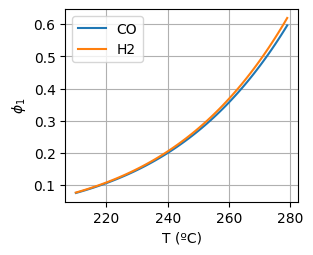

In [12]:
fig, ax = plt.subplots(figsize=(3,2.5))
sns.lineplot(x='T (ºC)', y = 'phi_CO', data=parametric_data, ax = ax, label = 'CO')
sns.lineplot(x='T (ºC)', y = 'phi_H2', data=parametric_data, ax = ax, label = 'H2')


plt.grid('both')
plt.ylabel(r'$\phi_1$')
plt.xlabel('T (ºC)')
# fig_name = 'r_vs_P_CO.pdf'
# plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, 
#             bbox_inches = 'tight')
plt.show()

In [13]:
def phi_T(T, phi_220):
    phi_T = phi_220 * ( ( 493 / T ) * np.exp( - ( params['E_HCs'] / 8.314 ) * ( 1/T - 1/493 ) ) ) ** (1/2)
    return phi_T

In [14]:
T = np.linspace(200 + 273, 280 + 273, 100)

phi2 = phi_T(T, 2)
eff2 = np.tanh(phi2)/phi2

phi4 = phi_T(T, 4)
eff4 = np.tanh(phi4)/phi4

phi10 = phi_T(T, 10)
eff10 = np.tanh(phi10)/phi10

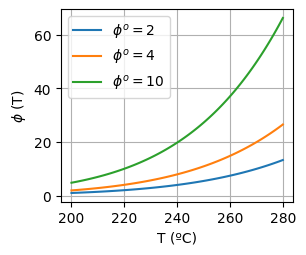

In [15]:
fig, ax = plt.subplots(figsize=(3,2.5))
plt.plot(T - 273, phi2, label = r'$\phi^o = 2$')
plt.plot(T - 273, phi4, label = r'$\phi^o = 4$')
plt.plot(T - 273, phi10, label = r'$\phi^o = 10$')
plt.xlabel('T (ºC)')
plt.ylabel(r'$\phi$ (T)')
plt.legend()
plt.grid('both')

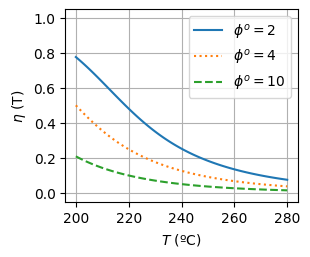

In [16]:
fig, ax = plt.subplots(figsize=(3,2.5))
plt.plot(T - 273, eff2, label = r'$\phi^o = 2$')
plt.plot(T - 273, eff4, label = r'$\phi^o = 4$', linestyle = ':')
plt.plot(T - 273, eff10, label = r'$\phi^o = 10$', linestyle = '--')
plt.xlabel(r'$T$ (ºC)')
plt.ylabel(r'$\eta$ (T)')
plt.grid('both')
plt.legend()
plt.ylim(-0.05, 1.05)
fig_name = 'eta.pdf'
plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, 
            bbox_inches = 'tight')

In [17]:
1.648*0.25

0.412